In [1]:
import os
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity,
    mean_squared_error
)

print("Degradation-Aware Residual U-Net SR")
print("PyTorch:", torch.__version__)

Degradation-Aware Residual U-Net SR
PyTorch: 2.5.1+cu121


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Seed:", SEED)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)

Seed: 42
Device: cuda
GPU: Quadro GV100
CUDA: 12.1


In [3]:
GT_PATH = "../data/train/GT"
NOISY_PATH = "../data/train/NoisyLR"

print(
    "GT exists:",
    os.path.exists(GT_PATH)
)

print(
    "NoisyLR exists:",
    os.path.exists(NOISY_PATH)
)

files = sorted([
    f
    for f in os.listdir(GT_PATH)
    if f.endswith(".npy")
])

print(
    "Total paired files:",
    len(files)
)

print(
    "First 5:",
    files[:5]
)

GT exists: True
NoisyLR exists: True
Total paired files: 3200
First 5: ['000000.npy', '000001.npy', '000002.npy', '000003.npy', '000004.npy']


In [4]:
np.random.seed(SEED)

indices = np.random.permutation(
    len(files)
)

train_end = int(
    0.80 * len(files)
)

val_end = int(
    0.90 * len(files)
)

train_files = [
    files[i]
    for i in indices[:train_end]
]

val_files = [
    files[i]
    for i in indices[
        train_end:val_end
    ]
]

test_files = [
    files[i]
    for i in indices[
        val_end:
    ]
]

print(
    "Train:",
    len(train_files)
)

print(
    "Validation:",
    len(val_files)
)

print(
    "Test:",
    len(test_files)
)

print(
    "\nValidation first 5:",
    val_files[:5]
)

print(
    "Test first 5:",
    test_files[:5]
)

Train: 2560
Validation: 320
Test: 320

Validation first 5: ['002105.npy', '000133.npy', '001140.npy', '000933.npy', '000928.npy']
Test first 5: ['001218.npy', '001158.npy', '001415.npy', '002896.npy', '001527.npy']


In [5]:
class KLADataset(Dataset):

    def __init__(
        self,
        gt_path,
        noisy_path,
        files
    ):

        self.gt_path = gt_path
        self.noisy_path = noisy_path
        self.files = files


    def __len__(self):

        return len(
            self.files
        )


    def __getitem__(
        self,
        idx
    ):

        filename = (
            self.files[idx]
        )

        lr = np.load(
            os.path.join(
                self.noisy_path,
                filename
            )
        ).astype(
            np.float32
        )

        gt = np.load(
            os.path.join(
                self.gt_path,
                filename
            )
        ).astype(
            np.float32
        )

        # IMPORTANT:
        # Do not clip noisy LR.
        # Out-of-range values are real degradation information.

        lr = torch.from_numpy(
            lr
        ).unsqueeze(0)

        gt = torch.from_numpy(
            gt
        ).unsqueeze(0)

        return lr, gt

In [6]:
BATCH_SIZE = 8

train_dataset = KLADataset(
    GT_PATH,
    NOISY_PATH,
    train_files
)

val_dataset = KLADataset(
    GT_PATH,
    NOISY_PATH,
    val_files
)

test_dataset = KLADataset(
    GT_PATH,
    NOISY_PATH,
    test_files
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(
    "Train:",
    len(train_dataset)
)

print(
    "Validation:",
    len(val_dataset)
)

print(
    "Test:",
    len(test_dataset)
)

Train: 2560
Validation: 320
Test: 320


In [7]:
sample_lr, sample_gt = (
    train_dataset[0]
)

print(
    "LR:",
    sample_lr.shape
)

print(
    "GT:",
    sample_gt.shape
)

print(
    "LR range:",
    float(sample_lr.min()),
    float(sample_lr.max())
)

print(
    "GT range:",
    float(sample_gt.min()),
    float(sample_gt.max())
)

LR: torch.Size([1, 128, 128])
GT: torch.Size([1, 256, 256])
LR range: -0.013836689293384552 1.4661262035369873
GT range: 0.0 1.0


In [8]:
class ResidualBlock(nn.Module):

    def __init__(
        self,
        channels
    ):

        super().__init__()

        self.conv1 = nn.Conv2d(
            channels,
            channels,
            3,
            padding=1
        )

        self.conv2 = nn.Conv2d(
            channels,
            channels,
            3,
            padding=1
        )

        self.act = nn.LeakyReLU(
            0.1,
            inplace=True
        )


    def forward(
        self,
        x
    ):

        residual = x

        x = self.conv1(
            x
        )

        x = self.act(
            x
        )

        x = self.conv2(
            x
        )

        return (
            residual
            +
            0.1 * x
        )

In [9]:
class EncoderBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.project = nn.Conv2d(
            in_channels,
            out_channels,
            3,
            padding=1
        )

        self.res1 = ResidualBlock(
            out_channels
        )

        self.res2 = ResidualBlock(
            out_channels
        )

        self.down = nn.Conv2d(
            out_channels,
            out_channels,
            3,
            stride=2,
            padding=1
        )


    def forward(
        self,
        x
    ):

        x = self.project(
            x
        )

        x = self.res1(
            x
        )

        x = self.res2(
            x
        )

        skip = x

        x = self.down(
            x
        )

        return (
            x,
            skip
        )

In [10]:
class DecoderBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        skip_channels,
        out_channels
    ):

        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.fuse = nn.Conv2d(
            out_channels
            +
            skip_channels,
            out_channels,
            3,
            padding=1
        )

        self.res1 = ResidualBlock(
            out_channels
        )

        self.res2 = ResidualBlock(
            out_channels
        )


    def forward(
        self,
        x,
        skip
    ):

        x = self.up(
            x
        )

        x = torch.cat(
            [
                x,
                skip
            ],
            dim=1
        )

        x = self.fuse(
            x
        )

        x = self.res1(
            x
        )

        x = self.res2(
            x
        )

        return x

In [11]:
class DegradationEstimator(nn.Module):

    def __init__(
        self,
        embedding_dim=16
    ):

        super().__init__()

        self.net = nn.Sequential(

            nn.Conv2d(
                1,
                8,
                3,
                padding=1
            ),

            nn.LeakyReLU(
                0.1,
                inplace=True
            ),

            nn.Conv2d(
                8,
                16,
                3,
                stride=2,
                padding=1
            ),

            nn.LeakyReLU(
                0.1,
                inplace=True
            ),

            nn.Conv2d(
                16,
                32,
                3,
                stride=2,
                padding=1
            ),

            nn.LeakyReLU(
                0.1,
                inplace=True
            ),

            nn.AdaptiveAvgPool2d(
                1
            ),

            nn.Flatten(),

            nn.Linear(
                32,
                embedding_dim
            )
        )


    def forward(
        self,
        x
    ):

        return self.net(
            x
        )

In [12]:
class DegradationModulation(nn.Module):

    def __init__(
        self,
        channels,
        embedding_dim=16
    ):

        super().__init__()

        self.fc = nn.Linear(
            embedding_dim,
            channels * 2
        )

        # Exact identity at initialization
        nn.init.zeros_(
            self.fc.weight
        )

        nn.init.zeros_(
            self.fc.bias
        )


    def forward(
        self,
        x,
        embedding
    ):

        params = self.fc(
            embedding
        )

        scale, shift = (
            params.chunk(
                2,
                dim=1
            )
        )

        scale = (
            scale[
                :,
                :,
                None,
                None
            ]
        )

        shift = (
            shift[
                :,
                :,
                None,
                None
            ]
        )

        return (
            x
            *
            (
                1.0
                +
                scale
            )
            +
            shift
        )

In [13]:
class DAResidualUNetSR(nn.Module):

    def __init__(
        self,
        base_channels=48,
        scale=2,
        embedding_dim=16
    ):

        super().__init__()


        # ==================================
        # Degradation estimator
        # ==================================

        self.degradation_estimator = (
            DegradationEstimator(
                embedding_dim
            )
        )


        # ==================================
        # SAME MODEL-10 BACKBONE
        # ==================================

        self.head = nn.Conv2d(
            1,
            base_channels,
            3,
            padding=1
        )


        self.enc1 = EncoderBlock(
            base_channels,
            base_channels
        )


        self.enc2 = EncoderBlock(
            base_channels,
            base_channels * 2
        )


        self.bottleneck_in = nn.Conv2d(
            base_channels * 2,
            base_channels * 3,
            3,
            padding=1
        )


        self.bottleneck = nn.Sequential(

            ResidualBlock(
                base_channels * 3
            ),

            ResidualBlock(
                base_channels * 3
            ),

            ResidualBlock(
                base_channels * 3
            ),

            ResidualBlock(
                base_channels * 3
            )
        )


        self.dec2 = DecoderBlock(
            base_channels * 3,
            base_channels * 2,
            base_channels * 2
        )


        self.dec1 = DecoderBlock(
            base_channels * 2,
            base_channels,
            base_channels
        )


        self.refine = nn.Sequential(

            ResidualBlock(
                base_channels
            ),

            ResidualBlock(
                base_channels
            )
        )


        self.up = nn.Sequential(

            nn.Conv2d(
                base_channels,
                base_channels
                *
                scale
                *
                scale,
                3,
                padding=1
            ),

            nn.PixelShuffle(
                scale
            ),

            nn.Conv2d(
                base_channels,
                1,
                3,
                padding=1
            )
        )


        # ==================================
        # ONLY NEW COMPONENTS
        # ==================================

        self.mod_skip1 = (
            DegradationModulation(
                base_channels,
                embedding_dim
            )
        )


        self.mod_skip2 = (
            DegradationModulation(
                base_channels * 2,
                embedding_dim
            )
        )


        self.mod_bottleneck = (
            DegradationModulation(
                base_channels * 3,
                embedding_dim
            )
        )


    def forward(
        self,
        x
    ):

        # Degradation embedding
        embedding = (
            self.degradation_estimator(
                x
            )
        )


        # Shallow features
        features = self.head(
            x
        )

        shallow = features


        # Encoder 1
        features, skip1 = (
            self.enc1(
                features
            )
        )

        skip1 = self.mod_skip1(
            skip1,
            embedding
        )


        # Encoder 2
        features, skip2 = (
            self.enc2(
                features
            )
        )

        skip2 = self.mod_skip2(
            skip2,
            embedding
        )


        # Bottleneck
        features = (
            self.bottleneck_in(
                features
            )
        )

        features = (
            self.bottleneck(
                features
            )
        )

        features = (
            self.mod_bottleneck(
                features,
                embedding
            )
        )


        # Decoder
        features = self.dec2(
            features,
            skip2
        )

        features = self.dec1(
            features,
            skip1
        )


        # Refinement
        features = self.refine(
            features
        )


        # Same long residual as Model 10
        features = (
            features
            +
            shallow
        )


        # x2 reconstruction
        output = self.up(
            features
        )

        return output

In [14]:
model = DAResidualUNetSR(
    base_channels=48,
    scale=2,
    embedding_dim=16
).to(
    device
)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    "Architecture:",
    model.__class__.__name__
)

print(
    f"Total parameters: "
    f"{total_params:,}"
)

print(
    f"Trainable parameters: "
    f"{trainable_params:,}"
)

Architecture: DAResidualUNetSR
Total parameters: 3,080,241
Trainable parameters: 3,080,241


In [15]:
dummy = torch.randn(
    2,
    1,
    128,
    128
).to(
    device
)

model.eval()

with torch.no_grad():

    output = model(
        dummy
    )

print(
    "Input:",
    dummy.shape
)

print(
    "Output:",
    output.shape
)

assert output.shape == (
    2,
    1,
    256,
    256
)

print(
    "Shape test PASSED"
)

Input: torch.Size([2, 1, 128, 128])
Output: torch.Size([2, 1, 256, 256])
Shape test PASSED


In [16]:
def gaussian_window(
    window_size=11,
    sigma=1.5,
    channels=1,
    device="cpu"
):

    coords = torch.arange(
        window_size,
        dtype=torch.float32,
        device=device
    )

    coords = (
        coords
        -
        window_size // 2
    )

    g = torch.exp(
        -(
            coords ** 2
        )
        /
        (
            2 * sigma ** 2
        )
    )

    g = (
        g
        /
        g.sum()
    )

    window = (
        g[:, None]
        *
        g[None, :]
    )

    return window.expand(
        channels,
        1,
        window_size,
        window_size
    )


def differentiable_ssim(
    x,
    y,
    window_size=11
):

    channels = (
        x.shape[1]
    )

    window = gaussian_window(
        window_size,
        1.5,
        channels,
        x.device
    )


    mu_x = F.conv2d(
        x,
        window,
        padding=window_size // 2,
        groups=channels
    )


    mu_y = F.conv2d(
        y,
        window,
        padding=window_size // 2,
        groups=channels
    )


    mu_x2 = (
        mu_x ** 2
    )

    mu_y2 = (
        mu_y ** 2
    )

    mu_xy = (
        mu_x * mu_y
    )


    sigma_x = (
        F.conv2d(
            x * x,
            window,
            padding=window_size // 2,
            groups=channels
        )
        -
        mu_x2
    )


    sigma_y = (
        F.conv2d(
            y * y,
            window,
            padding=window_size // 2,
            groups=channels
        )
        -
        mu_y2
    )


    sigma_xy = (
        F.conv2d(
            x * y,
            window,
            padding=window_size // 2,
            groups=channels
        )
        -
        mu_xy
    )


    C1 = (
        0.01 ** 2
    )

    C2 = (
        0.03 ** 2
    )


    ssim_map = (
        (
            2 * mu_xy + C1
        )
        *
        (
            2 * sigma_xy + C2
        )
    ) / (
        (
            mu_x2
            +
            mu_y2
            +
            C1
        )
        *
        (
            sigma_x
            +
            sigma_y
            +
            C2
        )
        +
        1e-8
    )


    return (
        ssim_map.mean()
    )


print(
    "SSIM ready"
)

SSIM ready


In [17]:
def restoration_loss(
    output,
    target
):

    l1 = F.l1_loss(
        output,
        target
    )

    ssim_value = (
        differentiable_ssim(
            output,
            target
        )
    )

    ssim_loss = (
        1.0
        -
        ssim_value
    )

    total_loss = (
        l1
        +
        0.10
        *
        ssim_loss
    )

    return (
        total_loss,
        l1,
        ssim_loss
    )


print(
    "Loss ready"
)

Loss ready


In [18]:
EPOCHS = 30

optimizer = optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-4
)

scheduler = (
    optim.lr_scheduler
    .CosineAnnealingLR(
        optimizer,
        T_max=EPOCHS,
        eta_min=1e-6
    )
)

print(
    "Optimizer ready"
)

Optimizer ready


In [19]:
MODEL_DIR = (
    "../models/"
    "da_resunet_sr_v2"
)

RESULT_DIR = (
    "../results/"
    "da_resunet_sr_v2"
)

RESTORED_DIR = (
    "../results/"
    "da_resunet_sr_v2/"
    "restored"
)

IMAGE_DIR = (
    "../results/"
    "da_resunet_sr_v2/"
    "images"
)

for path in [
    MODEL_DIR,
    RESULT_DIR,
    RESTORED_DIR,
    IMAGE_DIR
]:

    os.makedirs(
        path,
        exist_ok=True
    )


BEST_MODEL_PATH = (
    os.path.join(
        MODEL_DIR,
        "da_resunet_sr_v2_best.pth"
    )
)

print(
    "Best model path:",
    BEST_MODEL_PATH
)

Best model path: ../models/da_resunet_sr_v2/da_resunet_sr_v2_best.pth


In [20]:
def evaluate_validation(
    model,
    loader
):

    model.eval()

    psnr_values = []
    ssim_values = []


    with torch.no_grad():

        for lr, gt in loader:

            lr = lr.to(
                device,
                non_blocking=True
            )

            output = model(
                lr
            )


            output = torch.clamp(
                output,
                0,
                1
            )


            output_np = (
                output
                .cpu()
                .numpy()
            )


            gt_np = (
                gt
                .numpy()
            )


            for i in range(
                output_np.shape[0]
            ):

                pred = (
                    output_np[
                        i,
                        0
                    ]
                )

                target = (
                    gt_np[
                        i,
                        0
                    ]
                )


                psnr_values.append(
                    peak_signal_noise_ratio(
                        target,
                        pred,
                        data_range=1.0
                    )
                )


                ssim_values.append(
                    structural_similarity(
                        target,
                        pred,
                        data_range=1.0
                    )
                )


    return (
        float(
            np.mean(
                psnr_values
            )
        ),
        float(
            np.mean(
                ssim_values
            )
        )
    )

In [21]:
best_psnr = -1.0

train_history = []
val_psnr_history = []
val_ssim_history = []


for epoch in range(
    EPOCHS
):

    # ====================================
    # TRAIN
    # ====================================

    model.train()

    running_loss = 0.0


    train_bar = tqdm(
        train_loader,
        desc=(
            f"Epoch "
            f"{epoch+1}/{EPOCHS}"
        )
    )


    for lr, gt in train_bar:

        lr = lr.to(
            device,
            non_blocking=True
        )

        gt = gt.to(
            device,
            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        output = model(
            lr
        )


        loss, _, _ = (
            restoration_loss(
                output,
                gt
            )
        )


        loss.backward()


        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )


        optimizer.step()


        running_loss += (
            loss.item()
        )


        train_bar.set_postfix(
            loss=(
                f"{loss.item():.5f}"
            )
        )


    train_loss = (
        running_loss
        /
        len(train_loader)
    )


    # ====================================
    # VALIDATION
    # ====================================

    val_psnr, val_ssim = (
        evaluate_validation(
            model,
            val_loader
        )
    )


    train_history.append(
        train_loss
    )

    val_psnr_history.append(
        val_psnr
    )

    val_ssim_history.append(
        val_ssim
    )


    scheduler.step()


    current_lr = (
        optimizer
        .param_groups[0]["lr"]
    )


    print(
        f"Epoch "
        f"[{epoch+1:02d}/{EPOCHS}] "
        f"Loss: {train_loss:.6f} | "
        f"PSNR: {val_psnr:.4f} dB | "
        f"SSIM: {val_ssim:.4f} | "
        f"LR: {current_lr:.7f}"
    )


    # ====================================
    # BEST MODEL BY VALIDATION PSNR
    # ====================================

    if val_psnr > best_psnr:

        best_psnr = (
            val_psnr
        )


        checkpoint = {

            "epoch":
                epoch + 1,

            "model_state_dict":
                model.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict(),

            "scheduler_state_dict":
                scheduler.state_dict(),

            "val_psnr":
                val_psnr,

            "val_ssim":
                val_ssim,

            "config": {

                "base_channels":
                    48,

                "scale":
                    2,

                "embedding_dim":
                    16
            }
        }


        torch.save(
            checkpoint,
            BEST_MODEL_PATH
        )


        print(
            "★ Best model saved"
        )

Epoch 1/30: 100%|██████████| 320/320 [00:47<00:00,  6.68it/s, loss=0.08076]


Epoch [01/30] Loss: 0.088961 | PSNR: 25.6147 dB | SSIM: 0.6381 | LR: 0.0001995
★ Best model saved


Epoch 2/30: 100%|██████████| 320/320 [00:47<00:00,  6.75it/s, loss=0.06606]


Epoch [02/30] Loss: 0.071507 | PSNR: 26.5194 dB | SSIM: 0.6878 | LR: 0.0001978
★ Best model saved


Epoch 3/30: 100%|██████████| 320/320 [00:36<00:00,  8.82it/s, loss=0.03946]


...

Epoch [28/30] Loss: 0.053258 | PSNR: 28.2399 dB | SSIM: 0.7668 | LR: 0.0000032
★ Best model saved


Epoch 29/30: 100%|██████████| 320/320 [01:07<00:00,  4.73it/s, loss=0.03550]


Epoch [29/30] Loss: 0.053232 | PSNR: 28.2373 dB | SSIM: 0.7669 | LR: 0.0000015


Epoch 30/30: 100%|██████████| 320/320 [01:00<00:00,  5.27it/s, loss=0.05578]


Epoch [30/30] Loss: 0.053220 | PSNR: 28.2436 dB | SSIM: 0.7669 | LR: 0.0000010
★ Best model saved


In [22]:
history_df = pd.DataFrame({

    "Epoch":
        range(
            1,
            len(train_history)
            +
            1
        ),

    "Train_Loss":
        train_history,

    "Val_PSNR":
        val_psnr_history,

    "Val_SSIM":
        val_ssim_history
})


history_df.to_csv(
    os.path.join(
        RESULT_DIR,
        "training_history.csv"
    ),
    index=False
)


display(
    history_df.tail()
)

,Epoch,Train_Loss,Val_PSNR,Val_SSIM
25,26,0.053334,28.188392,0.766706
26,27,0.053297,28.239792,0.766087
27,28,0.053258,28.239885,0.766754
28,29,0.053232,28.237301,0.766919
29,30,0.053220,28.243584,0.766925


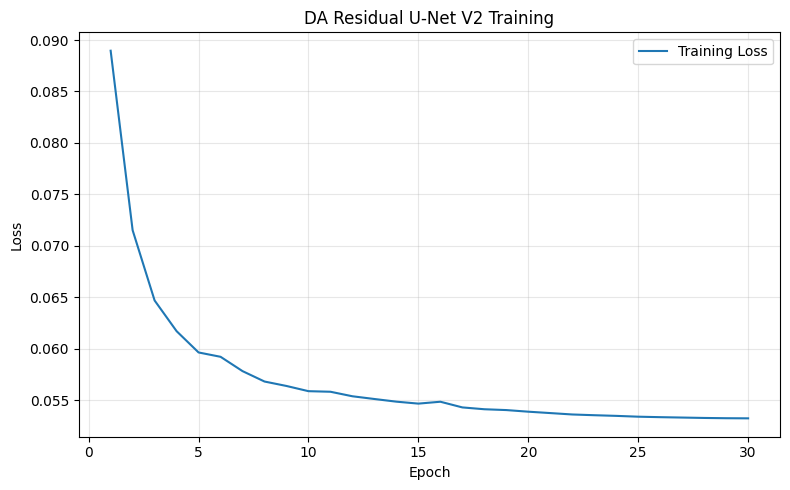

In [23]:
epochs = np.arange(
    1,
    len(train_history)
    +
    1
)


plt.figure(
    figsize=(8,5)
)

plt.plot(
    epochs,
    train_history,
    label="Training Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "DA Residual U-Net V2 Training"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        IMAGE_DIR,
        "training_loss.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device
)

best_model = DAResidualUNetSR(
    base_channels=
        checkpoint[
            "config"
        ][
            "base_channels"
        ],

    scale=
        checkpoint[
            "config"
        ][
            "scale"
        ],

    embedding_dim=
        checkpoint[
            "config"
        ][
            "embedding_dim"
        ]
).to(
    device
)


best_model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)


best_model.eval()


print(
    "Best epoch:",
    checkpoint["epoch"]
)

print(
    "Validation PSNR:",
    checkpoint["val_psnr"]
)

print(
    "Validation SSIM:",
    checkpoint["val_ssim"]
)

/tmp/ipykernel_3641877/299594498.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


Best epoch: 30
Validation PSNR: 28.24358353506654
Validation SSIM: 0.7669245292121672


In [25]:
psnr_scores = []
ssim_scores = []
mse_scores = []
inference_times = []


best_model.eval()


with torch.no_grad():

    for i, (
        lr,
        gt
    ) in enumerate(
        tqdm(
            test_loader,
            desc="Testing DA Residual U-Net V2"
        )
    ):


        lr = lr.to(
            device,
            non_blocking=True
        )


        if device.type == "cuda":
            torch.cuda.synchronize()


        start = (
            time.perf_counter()
        )


        output = (
            best_model(
                lr
            )
        )


        if device.type == "cuda":
            torch.cuda.synchronize()


        elapsed_ms = (
            time.perf_counter()
            -
            start
        ) * 1000


        output = torch.clamp(
            output,
            0,
            1
        )


        restored = (
            output
            .squeeze()
            .cpu()
            .numpy()
        )


        gt_np = (
            gt
            .squeeze()
            .numpy()
        )


        psnr_value = (
            peak_signal_noise_ratio(
                gt_np,
                restored,
                data_range=1.0
            )
        )


        ssim_value = (
            structural_similarity(
                gt_np,
                restored,
                data_range=1.0
            )
        )


        mse_value = (
            mean_squared_error(
                gt_np,
                restored
            )
        )


        psnr_scores.append(
            psnr_value
        )

        ssim_scores.append(
            ssim_value
        )

        mse_scores.append(
            mse_value
        )

        inference_times.append(
            elapsed_ms
        )


        filename = (
            test_files[i]
        )


        np.save(
            os.path.join(
                RESTORED_DIR,
                filename
            ),
            restored.astype(
                np.float32
            )
        )


print(
    "Testing complete"
)

Testing DA Residual U-Net V2: 100%|██████████| 320/320 [00:05<00:00, 62.77it/s]

Testing complete


In [26]:
metrics_df = pd.DataFrame({

    "Filename":
        test_files,

    "PSNR_dB":
        psnr_scores,

    "SSIM":
        ssim_scores,

    "MSE":
        mse_scores,

    "Inference_Time_ms":
        inference_times
})


metrics_df.to_csv(
    os.path.join(
        RESULT_DIR,
        "per_image_metrics.csv"
    ),
    index=False
)


display(
    metrics_df.head()
)

,Filename,PSNR_dB,SSIM,MSE,Inference_Time_ms
0,001218.npy,27.696557,0.796987,0.001700,72.826983
1,001158.npy,28.230462,0.555406,0.001503,8.600844
2,001415.npy,21.872782,0.759415,0.006497,9.928214
3,002896.npy,29.710269,0.825788,0.001069,10.009222
4,001527.npy,38.920734,0.947313,0.000128,8.562031


In [27]:
avg_psnr = float(
    np.mean(
        psnr_scores
    )
)

median_psnr = float(
    np.median(
        psnr_scores
    )
)

avg_ssim = float(
    np.mean(
        ssim_scores
    )
)

median_ssim = float(
    np.median(
        ssim_scores
    )
)

avg_mse = float(
    np.mean(
        mse_scores
    )
)

avg_time = float(
    np.mean(
        inference_times
    )
)


print(
    "========== DA RESIDUAL U-NET V2 FINAL RESULTS =========="
)

print(
    f"Average PSNR : "
    f"{avg_psnr:.6f} dB"
)

print(
    f"Median  PSNR : "
    f"{median_psnr:.6f} dB"
)

print(
    f"Average SSIM : "
    f"{avg_ssim:.6f}"
)

print(
    f"Median  SSIM : "
    f"{median_ssim:.6f}"
)

print(
    f"Average MSE  : "
    f"{avg_mse:.8f}"
)

print(
    f"Average inference time : "
    f"{avg_time:.3f} ms/image"
)

print(
    "Images tested:",
    len(psnr_scores)
)

========== DA RESIDUAL U-NET V2 FINAL RESULTS ==========
Average PSNR : 28.771419 dB
Median  PSNR : 28.705185 dB
Average SSIM : 0.772428
Median  SSIM : 0.804300
Average MSE  : 0.00226632
Average inference time : 7.571 ms/image
Images tested: 320


In [28]:
MODEL10_PSNR = 28.776597
MODEL10_SSIM = 0.772058
MODEL10_MSE  = 0.002261


print(
    "========== MODEL 11 V2 vs MODEL 10 =========="
)


print(
    f"PSNR difference : "
    f"{avg_psnr - MODEL10_PSNR:+.4f} dB"
)


print(
    f"SSIM difference : "
    f"{avg_ssim - MODEL10_SSIM:+.4f}"
)


print(
    f"MSE difference  : "
    f"{avg_mse - MODEL10_MSE:+.8f}"
)

========== MODEL 11 V2 vs MODEL 10 ==========
PSNR difference : -0.0052 dB
SSIM difference : +0.0004
MSE difference  : +0.00000532


In [29]:
MODEL10_PSNR = 28.776597
MODEL10_SSIM = 0.772058
MODEL10_MSE  = 0.002261


print(
    "========== MODEL 11 V2 vs MODEL 10 =========="
)


print(
    f"PSNR difference : "
    f"{avg_psnr - MODEL10_PSNR:+.4f} dB"
)


print(
    f"SSIM difference : "
    f"{avg_ssim - MODEL10_SSIM:+.4f}"
)


print(
    f"MSE difference  : "
    f"{avg_mse - MODEL10_MSE:+.8f}"
)

========== MODEL 11 V2 vs MODEL 10 ==========
PSNR difference : -0.0052 dB
SSIM difference : +0.0004
MSE difference  : +0.00000532


In [30]:
comparison_df = pd.DataFrame({

    "Method": [
        "Bicubic",
        "SRCNN",
        "DnCNN",
        "EDSR",
        "NAF-SR",
        "Residual U-Net SR",
        "DA Residual U-Net V2"
    ],

    "PSNR_dB": [
        22.478415628140233,
        27.52943205674495,
        27.893001035080903,
        27.986647229958713,
        27.840080,
        28.776597,
        avg_psnr
    ],

    "SSIM": [
        0.5116624465067319,
        0.7250710888767316,
        0.7249596254696442,
        0.7425061760836545,
        0.743259,
        0.772058,
        avg_ssim
    ],

    "MSE": [
        0.007338321273890881,
        0.0027344456903774946,
        0.0025748269964531107,
        0.0026003361484997337,
        0.00266457,
        0.002261,
        avg_mse
    ]
})


comparison_df.to_csv(
    os.path.join(
        RESULT_DIR,
        "baseline_comparison.csv"
    ),
    index=False
)


display(
    comparison_df
)

,Method,PSNR_dB,SSIM,MSE
0,Bicubic,22.478416,0.511662,0.007338
1,SRCNN,27.529432,0.725071,0.002734
2,DnCNN,27.893001,0.724960,0.002575
3,EDSR,27.986647,0.742506,0.002600
4,NAF-SR,27.840080,0.743259,0.002665
5,Residual U-Net SR,28.776597,0.772058,0.002261
6,DA Residual U-Net V2,28.771419,0.772428,0.002266


In [31]:
best_epoch = (
    checkpoint[
        "epoch"
    ]
)


with open(
    os.path.join(
        RESULT_DIR,
        "metrics.txt"
    ),
    "w"
) as f:

    f.write(
        "DA Residual U-Net SR V2\n"
    )

    f.write(
        "========================\n\n"
    )

    f.write(
        f"Best epoch: "
        f"{best_epoch}\n"
    )

    f.write(
        f"PSNR: "
        f"{avg_psnr:.6f} dB\n"
    )

    f.write(
        f"SSIM: "
        f"{avg_ssim:.6f}\n"
    )

    f.write(
        f"MSE: "
        f"{avg_mse:.8f}\n"
    )

    f.write(
        f"Inference time: "
        f"{avg_time:.3f} ms/image\n"
    )

    f.write(
        "\nModel 10 reference:\n"
    )

    f.write(
        "PSNR: 28.776597\n"
    )

    f.write(
        "SSIM: 0.772058\n"
    )

    f.write(
        "MSE: 0.002261\n"
    )


print(
    "Experiment summary saved"
)

Experiment summary saved


In [1]:
import json

nb_path = "11_degradation_aware_resunet_sr.ipynb"

with open(nb_path, "r") as f:
    nb = json.load(f)


for i,cell in enumerate(nb["cells"]):

    if cell["cell_type"] == "code":

        code = "".join(cell["source"])

        classes = [
            "class ResidualBlock",
            "class EncoderBlock",
            "class DecoderBlock",
            "class DegradationEstimator",
            "class DegradationModulation",
            "class DAResidualUNetSR"
        ]

        found=[]

        for c in classes:
            if c in code:
                found.append(c)


        if found:
            print("\nCELL NUMBER:",i)
            print(found)


CELL NUMBER: 9
['class ResidualBlock']

CELL NUMBER: 10
['class EncoderBlock']

CELL NUMBER: 11
['class DecoderBlock']

CELL NUMBER: 12
['class DegradationEstimator']

CELL NUMBER: 13
['class DegradationModulation']

CELL NUMBER: 14
['class DAResidualUNetSR']


In [3]:
import torch

checkpoint = torch.load(
    "../models/da_resunet_sr_v2/da_resunet_sr_v2_best.pth",
    map_location="cpu"
)

print(checkpoint.keys())

print(checkpoint["config"])

/tmp/ipykernel_208166/3066892948.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'val_psnr', 'val_ssim', 'config'])
{'base_channels': 48, 'scale': 2, 'embedding_dim': 16}
